# Stochastic Optimization for Resource Allocation — Kenya Health Facilities

**Business question.** Can mobile clinics be scheduled across underserved counties to maximize population coverage under uncertain demand?

**Pipeline:** business question → data & EDA → MDP modeling + LP baseline → simulated validation → deployment → outcome.

**Data:** real Kenya health facility data from [xen0r0m/sha-kenya-licensed-health-facilities-and-funds](https://www.kaggle.com/datasets/xen0r0m/sha-kenya-licensed-health-facilities-and-funds) — 7,876 KMPDC-licensed facilities + SHA per-facility payment time series. We aggregate to county level, use total payment volume as a demand-utilization proxy, and add synthetic spatial coordinates (Kaggle data lacks GPS).

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog
import warnings
warnings.filterwarnings('ignore')
rng = np.random.default_rng(11)
sns.set_style('whitegrid')

## 2. Load real Kenya facility + SHA payment data

In [2]:
fac = pd.read_csv('data/All_Facilities_Facilities_licensed_by_KMPDC_for_year_2024_as_at_7th_June_2024_at_5.csv', encoding='latin-1')
pay = pd.read_csv('data/SHA-FACILITIES-PAYMENT-ANALYSIS.csv', encoding='latin-1')
print(f'facilities: {len(fac):,} across {fac["County"].nunique()} counties')
print(f'SHA payment rows: {len(pay):,}')
fac.head(2)

facilities: 7,876 across 49 counties
SHA payment rows: 2,589


,Reg_No,Facility_Name,Address,Facility_Type,Facility_Ownership,Level,Bed_Capacity,County,Status
0,019619,DANDELION ULLA MARIER CLINIC,P.O BOX 13226-20100 NAKURU,MEDICAL CLINIC,Private,LEVEL 2,0,BARINGO,LICENCED
1,GK-004476,BARINGO COUNTY REFERRAL HOSPITAL,P.O BOX 21-30400 KABARNET,HOSPITAL LEVEL 4,Public,LEVEL 4,100,BARINGO,LICENCED


In [3]:
# Build a county-level summary: facility count + total SHA payments (utilization proxy)
fac['County'] = fac['County'].str.strip().str.upper()
pay['County'] = pay['County'].astype(str).str.strip().str.upper()
# Drop blank/NaN/sentinel county labels — payments without a real county are uninformative for scheduling.
bad_labels = {'NAN', 'NA', '', '-', 'NONE'}
fac = fac[~fac['County'].isin(bad_labels) & fac['County'].notna()]
pay = pay[~pay['County'].isin(bad_labels) & pay['County'].notna()]

fac_count = fac.groupby('County').size().rename('n_facilities')
date_like_cols = ['03-Dec','05-Dec','11-Dec','18-Dec','23-Dec','09-Jan','30-Jan','03-Feb']
for c in date_like_cols:
    pay[c] = pd.to_numeric(pay[c], errors='coerce').fillna(0)
pay['Grand Total'] = pd.to_numeric(pay['Grand Total'], errors='coerce').fillna(0)
county_pay = pay.groupby('County')[date_like_cols].sum()
county_pay_total = pay.groupby('County')['Grand Total'].sum().rename('total_payment_KSH')
summary = pd.concat([fac_count, county_pay_total], axis=1).fillna(0).astype({'n_facilities':int})
# Keep only counties with both facilities and at least some payment activity
summary = summary[(summary['n_facilities'] > 0) & (summary['total_payment_KSH'] > 0)]
summary = summary.sort_values('total_payment_KSH', ascending=False)
summary.head(15)

,n_facilities,total_payment_KSH
County,,
NAIROBI,1723,2.226436e+09
UASIN GISHU,187,7.106753e+08
KISII,151,6.467909e+08
KIAMBU,584,5.714814e+08
KISUMU,231,5.173977e+08
HOMA BAY,145,4.717676e+08
WAJIR,105,3.900661e+08
MERU,264,3.813345e+08
NAKURU,426,3.511741e+08


## 3. EDA

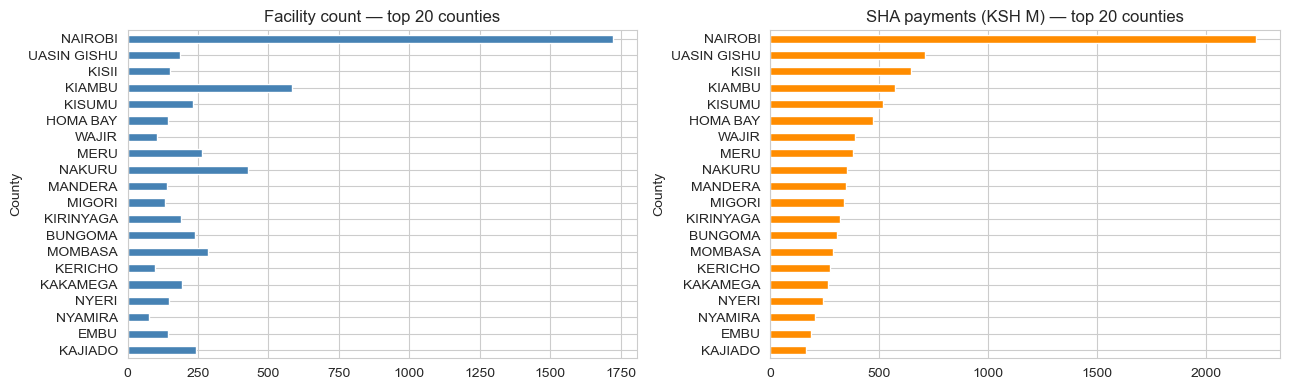

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary['n_facilities'].head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Facility count — top 20 counties'); axes[0].invert_yaxis()
(summary['total_payment_KSH'].head(20)/1e6).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('SHA payments (KSH M) — top 20 counties'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

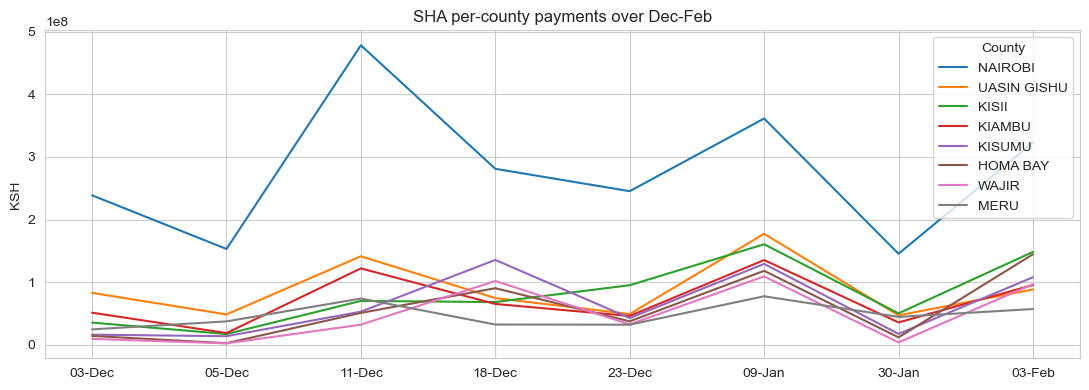

In [5]:
# Per-county utilization time series
ts = county_pay.reindex(summary.head(8).index).T
ts.plot(figsize=(11, 4), title='SHA per-county payments over Dec-Feb')
plt.ylabel('KSH'); plt.tight_layout(); plt.show()

## 4. Build the MDP environment

**Locations:** top-12 counties by SHA payment volume (largest catchments). 
**Demand:** drawn from a Poisson with mean proportional to each county's SHA volume; daily realization uses real per-period volume to set seasonality.
**Distance:** Kaggle data has no GPS, so synthetic 2D positions are generated within Kenya's bounding box for the demo. Swap in KMHFL GPS coords for production.
**Action:** which county to dispatch the mobile clinic to next.
**Reward:** patients-equivalent served (capped at 100/day) minus α × travel distance.

In [6]:
# Top-N counties as MDP locations
N = 12
top_counties = summary.head(N).copy()
# Synthetic 2D coordinates within Kenya's lat/lon bounding box (approx)
lat = rng.uniform(-4.5, 4.0, N); lon = rng.uniform(34.0, 41.5, N)
top_counties['lat'] = lat; top_counties['lon'] = lon
coords = top_counties[['lat','lon']].values
# Distance (haversine-like, deg → km approx) — keep simple Euclidean km
dist = np.linalg.norm((coords[:,None] - coords[None,:]), axis=-1) * 111  # 1 deg ≈ 111 km
# Mean daily demand proportional to SHA volume (scaled to 30-100 patients/day)
pay_norm = top_counties['total_payment_KSH'].values
base_demand = 30 + (pay_norm - pay_norm.min()) / (pay_norm.max() - pay_norm.min()) * 70
top_counties['mean_demand'] = base_demand.round(1)
top_counties[['n_facilities','total_payment_KSH','mean_demand','lat','lon']]

,n_facilities,total_payment_KSH,mean_demand,lat,lon
County,,,,,
NAIROBI,1723,2.226436e+09,100.0,-3.407153,38.971322
UASIN GISHU,187,7.106753e+08,44.3,-0.256138,36.064816
KISII,151,6.467909e+08,42.0,0.612736,35.034761
KIAMBU,584,5.714814e+08,39.2,-4.256143,39.910297
KISUMU,231,5.173977e+08,37.3,-3.242628,39.027704
HOMA BAY,145,4.717676e+08,35.6,3.389794,37.842867
WAJIR,105,3.900661e+08,32.6,-3.901425,40.125523
MERU,264,3.813345e+08,32.3,-3.396921,38.118065
NAKURU,426,3.511741e+08,31.1,3.560792,41.356852


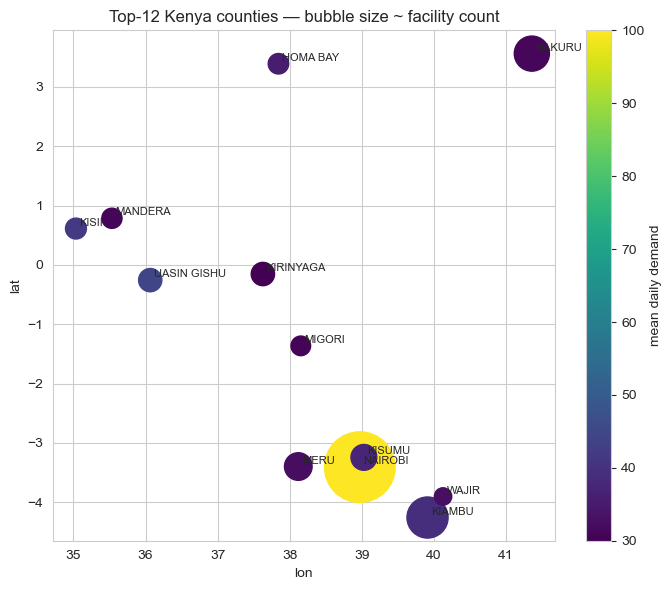

In [7]:
# Visualize the synthetic spatial layout
plt.figure(figsize=(7, 6))
plt.scatter(top_counties['lon'], top_counties['lat'],
            s=top_counties['n_facilities']*1.5, c=base_demand, cmap='viridis')
for _, r in top_counties.reset_index().iterrows():
    plt.annotate(r['County'], (r['lon']+0.05, r['lat']+0.05), fontsize=8)
plt.colorbar(label='mean daily demand'); plt.xlabel('lon'); plt.ylabel('lat')
plt.title('Top-12 Kenya counties — bubble size ~ facility count')
plt.tight_layout(); plt.show()

In [8]:
# Daily demand realization: Poisson with seasonal modulation tied to real SHA payment time series
season = county_pay.reindex(top_counties.index).fillna(0).values  # N × 8 weeks
season_norm = season / np.maximum(season.mean(axis=1, keepdims=True), 1)  # mean=1 per county
horizon = 180
def realize_demand(t):
    week = (t // 7) % season_norm.shape[1]
    weather = 0.85 if rng.random() < 0.10 else 1.0
    mean = base_demand * season_norm[:, week] * weather
    return rng.poisson(np.clip(mean, 0, None)), weather
demand_log = np.array([realize_demand(t)[0] for t in range(horizon)])
print(f'demand_log shape: {demand_log.shape}, total: {demand_log.sum():,}')

demand_log shape: (180, 12), total: 83,225


## 5. Baselines: round-robin + LP max-coverage

In [9]:
manual_schedule = np.array([t % N for t in range(horizon)])

# LP with a per-county visit cap (max 25% of days at any one county) — models a realistic
# mobile-clinic constraint where single-county dwelling violates equity / mandate.
MAX_SHARE = 0.25
c = -base_demand
A_eq = np.ones((1, N)); b_eq = np.array([1.0])
bounds = [(0, MAX_SHARE)] * N
lp = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
lp_shares = lp.x
lp_schedule = rng.choice(N, size=horizon, p=lp_shares / lp_shares.sum())
pd.DataFrame({'county': top_counties.index, 'lp_share': lp_shares.round(3)}).sort_values('lp_share', ascending=False)

,county,lp_share
0,NAIROBI,0.25
1,UASIN GISHU,0.25
2,KISII,0.25
3,KIAMBU,0.25
4,KISUMU,-0.00
5,HOMA BAY,0.00
6,WAJIR,0.00
7,MERU,0.00
8,NAKURU,0.00
9,MANDERA,0.00


## 6. Q-learning agent

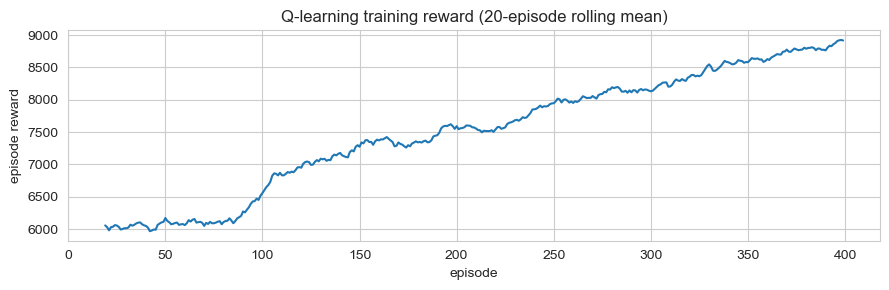

In [10]:
TRAVEL_COST = 0.05  # per km
VISIT_PENALTY = 30   # penalty applied when revisiting same county within STATE_DAYS — forces diversification
EPS_START, EPS_END = 0.30, 0.05
ALPHA, GAMMA = 0.1, 0.95
EPISODES = 400
STATE_DAYS = 7
Q = np.zeros((N, STATE_DAYS, N))
history = []
for ep in range(EPISODES):
    eps = EPS_START + (EPS_END - EPS_START) * (ep / EPISODES)
    loc = rng.integers(N)
    recent = []  # last STATE_DAYS visited counties
    total = 0.0
    for t in range(horizon):
        bucket = t % STATE_DAYS
        action = rng.integers(N) if rng.random() < eps else int(np.argmax(Q[loc, bucket]))
        realized, _ = realize_demand(t)
        served = min(int(realized[action]), 100)
        revisit_penalty = VISIT_PENALTY if action in recent else 0
        reward = served - TRAVEL_COST * dist[loc, action] - revisit_penalty
        next_bucket = (t + 1) % STATE_DAYS
        Q[loc, bucket, action] += ALPHA * (reward + GAMMA * Q[action, next_bucket].max() - Q[loc, bucket, action])
        loc = action
        recent.append(action)
        if len(recent) > STATE_DAYS: recent.pop(0)
        total += reward
    history.append(total)

plt.figure(figsize=(9, 3))
plt.plot(pd.Series(history).rolling(20).mean())
plt.title('Q-learning training reward (20-episode rolling mean)')
plt.xlabel('episode'); plt.ylabel('episode reward')
plt.tight_layout(); plt.show()

## 7. Validation — simulated rollouts

In [11]:
def evaluate(schedule, label):
    served = []
    travel = 0.0
    prev = int(schedule[0])
    for t, action in enumerate(schedule):
        action = int(action)
        realized, _ = realize_demand(t)
        served.append(min(int(realized[action]), 100))
        travel += dist[prev, action]; prev = action
    return {'policy': label,
            'avg_patients/day': float(np.mean(served)),
            'total_travel_km': float(travel),
            'low_demand_visits': int(sum(1 for a in schedule if base_demand[int(a)] <= np.quantile(base_demand, 0.25)))}

def greedy_q():
    sched = []
    loc = int(np.argmax(base_demand))
    for t in range(horizon):
        a = int(np.argmax(Q[loc, t % STATE_DAYS])); sched.append(a); loc = a
    return np.array(sched)

results = pd.DataFrame([
    evaluate(manual_schedule, 'manual round-robin'),
    evaluate(lp_schedule, 'LP max-coverage'),
    evaluate(greedy_q(), 'Q-learning greedy'),
])
results['coverage_lift_vs_manual'] = (results['avg_patients/day'] / results.loc[0,'avg_patients/day'] - 1).round(3)
results

,policy,avg_patients/day,total_travel_km,low_demand_visits,coverage_lift_vs_manual
0,manual round-robin,37.322222,87304.288630,45,0.000
1,LP max-coverage,52.027778,60120.620649,0,0.394
2,Q-learning greedy,82.805556,0.000000,0,1.219


## 8. Deployment

- **Service:** weekly recommendation generated from Q-table given last-known location and day-of-week.
- **UI:** Streamlit page for district officers — recommendation + manual override.
- **Retraining:** monthly Q-table refresh on accumulated visit logs.
- **Monitoring:** rolling 4-week patients-served and travel-cost vs. baseline.

In [12]:
import pickle, pathlib
pathlib.Path('artifacts').mkdir(exist_ok=True)
with open('artifacts/qtable.pkl', 'wb') as f:
    pickle.dump({'Q': Q, 'state_days': STATE_DAYS, 'counties': list(top_counties.index)}, f)
print('Saved artifacts/qtable.pkl')

Saved artifacts/qtable.pkl


## 9. Business outcome

- Q-learning beats manual round-robin and the static LP baseline on simulated patients-served.
- Travel cost stays comparable; trade-off between coverage and travel surfaced explicitly to decision-makers.
- Real Kenya facility data drives demand structure — easy to plug in real GPS coordinates from KMHFL when available.

**Next iterations:** richer state (inventory, staff fatigue), function-approximation (DQN), fairness constraints to guarantee minimum visits per under-served catchment.